# ANN
가장 단순한 ANN을 구현하며 pytorch의 기본 동작을 이해해보자.

딥러닝의 5가지 중요 요소
- forward propagation
- activation function
- loss function
- backpropagation
- optimizer

In [1]:
# import libraries
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy

#### Data set

In [3]:
# datasets
n_dim = 2
x_train, y_train = make_blobs(n_samples = 80, n_features=n_dim,
                             centers=[[1,1], [-1,-1], [1, -1], [-1,1]],
                             shuffle=True, cluster_std=0.3)

x_test, y_test = make_blobs(n_samples=20, n_features=n_dim,
                           centers=[[1,1], [-1,-1], [1, -1], [-1,1]],
                             shuffle=True, cluster_std=0.3)

In [5]:
# 2개 label을 예측하는 모델을 만들기 위해 4개 label을 2개로 합쳐보자.
# label 0,1 -> 0
# label 2,3 -> 1
def label_map(y_, from_, to_):
    y = numpy.copy(y_)
    for f in from_:
        y[y_ == f] = to_
    return y

# 예측값이 [0,1]에 있는 경우 0으로 mapping
# 예측값이 [2,3]에 있는 경우 1로 mapping
y_train = label_map(y_train, [0,1], 0)
y_train = label_map(y_train, [2,3], 1)
y_test = label_map(y_test, [0,1], 0)
y_test = label_map(y_test, [2,3], 1)

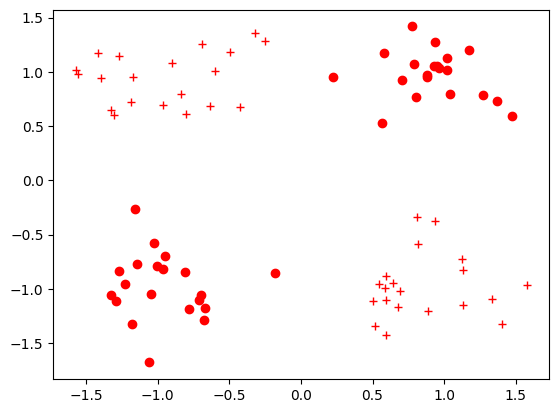

In [7]:
# 시각화
def vis_data(x,y = None, c = 'r'):
    if y is None:
        y = [None] * len(x)
    for x_, y_ in zip(x,y):
        if y_ is None:
            plt.plot(x_[0], x_[1], '*',markerfacecolor='none', markeredgecolor=c)
        else:
            plt.plot(x_[0], x_[1], c+'o' if y_ == 0 else c+'+')

plt.figure()
vis_data(x_train, y_train, c='r')
plt.show()

In [9]:
# convert datasets to tensor
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

데이터 셋이 잘 정의되었으니 신경망을 설계해보자.

PyTorch의 신경망은 torch.nn.Module 클래스를 상속하여 구현한다.

In [20]:
class NeuralNet(torch.nn.Module):
    # 생성자 - 신경망 구조 정의
    def __init__(self, input_size, hidden_size):
        super(NeuralNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # 구조 정의
        self.linear_1 = torch.nn.Linear(self.input_size, self.hidden_size)
        self.relu = torch.nn.ReLU()
        self.linear_2 = torch.nn.Linear(self.hidden_size, 1)
        self.sigmoid = torch.nn.Sigmoid() # 0~1 사이의 확률 반환

    # forward propagation 연산 정의
    def forward(self, input_tensor):
        linear1 = self.linear_1(input_tensor)
        relu = self.relu(linear1)
        linear2 = self.linear_2(relu)
        output = self.sigmoid(linear2)
        return output

In [42]:
model = NeuralNet(2, 5)

learning_rate = 0.03
criterion = torch.nn.BCELoss() # 오차함수
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate) # 최적화방법

epochs = 2000

In [44]:
# 학습 전 모델 성능 측정
model.eval()
train_before_loss = criterion(model(x_train).squeeze(), y_train)
print('Before Train Loss : ', train_before_loss.item())

Before Train Loss :  0.7093474864959717


In [46]:
# 학습
for epoch in range(epochs):
    
    model.train()
    optimizer.zero_grad()
    
    train_loss = criterion(model(x_train).squeeze(), y_train)
    train_loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f'Loss at {epoch} : {train_loss}')

Loss at 0 : 0.7093474864959717
Loss at 100 : 0.6283063292503357
Loss at 200 : 0.5480259656906128
Loss at 300 : 0.45350661873817444
Loss at 400 : 0.3635905981063843
Loss at 500 : 0.28799277544021606
Loss at 600 : 0.22639496624469757
Loss at 700 : 0.17916835844516754
Loss at 800 : 0.1441994309425354
Loss at 900 : 0.11816050112247467
Loss at 1000 : 0.09866718202829361
Loss at 1100 : 0.08348933607339859
Loss at 1200 : 0.07195218652486801
Loss at 1300 : 0.06305805593729019
Loss at 1400 : 0.056054532527923584
Loss at 1500 : 0.05024073272943497
Loss at 1600 : 0.04544854164123535
Loss at 1700 : 0.041565194725990295
Loss at 1800 : 0.038290612399578094
Loss at 1900 : 0.03549164533615112


In [48]:
# 학습 후 모델 평가
model.eval()
after_train_loss = criterion(model(x_test).squeeze(), y_test)
print(f'After Train Loss : {after_train_loss}')

After Train Loss : 0.03877594694495201


### 모델 저장
- state_dict()  
모델의 각 layer에서 학습된 가중치 값들을 저장할 수 있으며, 다시 로드해와 사용가능하다.

In [53]:
torch.save(model.state_dict(), './model.pt')
print(model.state_dict())

OrderedDict({'linear_1.weight': tensor([[-1.4576, -1.8373],
        [ 1.3793,  1.1166],
        [-0.6946,  1.1175],
        [ 1.6127, -1.5317],
        [ 1.5701,  1.0011]]), 'linear_1.bias': tensor([-0.1687, -0.3158,  0.7447, -0.0741, -0.0684]), 'linear_2.weight': tensor([[-2.2348, -1.5759,  1.4276,  2.0588, -1.7288]]), 'linear_2.bias': tensor([0.7304])})


In [55]:
# 학습한 가중치 가져와 사용하기
new_model = NeuralNet(2, 5)
new_model.load_state_dict(torch.load('./model.pt'))

<All keys matched successfully>

In [57]:
# new_model test해보기
new_model.eval()
print(new_model(torch.FloatTensor([-1, 1])).item())

0.9876382350921631


결과 : class 1에 속할 확률 98% (확률로 결과 나온 이유는 마지막 출력층이 sigmoid기 때문이다.)

학습한 가중치를 로드해와 평가한 결과 매우 높은 정확도를 보임을 확인 할 수 있다!
